<h1>Salary Predictions</h1>
Student: Tim Barker
<br>Instructor: Pramod Gupta, ME, PhD
<br>UC Davis Introduction to Machine Learning
<br>243PYT305 2024/25 Winter
<!--
0      Introduction
0.1    Background
0.2    Objectives
0.3    Dataset Selection
0.4    Survey Questions
1      Step 1 Load The Data Below
1.1    Import Modules
1.2    Read Data
1.3    Config Environment
2      Step 2 Describe the Data Below
2.1    General Info
2.2    Inspect Data
2.3    Describe Stats
2.4    Unique Value Counts
3      Step 3 Explore The Data Below
3.0    Column-specific Exploration
3.1.0  Survey Year
3.1.1  Timestamp
3.1.2  SalaryUSD
3.1.3  Country
3.1.4  PostalCode
3.1.5  PrimaryDatabase
3.1.6  YearsWithThisDatabase
3.1.7  OtherDatabases
3.1.8  EmploymentStatus
3.1.9  JobTitle
3.1.10 ManageStaff
3.1.11 YearsWithThisTypeOfJob
3.1.12 HowManyCompanies
3.1.13 OtherPeopleOnYourTeam
3.1.14 DatabaseServers
3.1.15 PopulationOfLargestCityWithin20Miles
3.1.16 EmploymentSector
3.1.17 CareerPlansThisYear
3.1.18 Gender
3.1.19 Counter
3.2    Missing Values
3.3    Histrogram of Numerical Columns
3.4    Boxplots for Feature Distributions
3.5    Correlation Heatmap
3.6    EDA Report
4      Step 4 Build The Model Below
4.1    Outliers
4.2    X and y Split
4.3    X Columns
4.4    Feature Importance
4.5    Build Data Cleaning Pipes
4.5.1  Functions
4.5.2  Imputers
4.5.3  Encoders
4.5.4  Column Transformers
4.6    Variance and Adjusted-R²
4.7    Build Modeling Pipes
4.7.1  Models
4.7.2  Train and Test Split
4.7.3  Fit Pipelines
5      Step 5 Evaluate The Model Performance
5.1    Ranked Models by R²
5.2    Predictive Performance
5.3    Error Magnitude
5.4    Computational Efficiency
5.5    Parallelization
6      Step 6 Describe And Interpret The Model
6.1    Actual vs Predicted SalaryUSD
6.2    Findings
6.2.1  Feature Importance
6.2.2  Feature Selection
6.2.3  Model Performance
6.2.4  Model Efficiency
6.3    Opportunities
7      Sources
-->

<h2 style='color: #ffffff; background-color: #85bb65;'>&nbsp;Introduction</h2>

In this report I present findings from an exploration of Brent Ozar's Data Professional Salary Survey<sup>[[1](#source1)]</sup> dataset which measures 19 variables related to salary for over 13,000 respondents over 8 years. Of primary interest is the respondent salaries, which is the self-reported annual earnings in USD.

### Background
Brent Ozar is a Microsoft SQL Server expert who provides specialized consulting and training services to organizations with high-performing SQL Server environments. He publishes YouTube videos, frequently speaks at major industry conferences, develops and distributes his diagnostic software the First Responder Kit for SQL Server developers and administrators. Each year, he conducts a survey to his followers asking them to anonymously self-report salaries, along with other details about their job, experience, and technical environments.

### Objectives
* Identify predictors within the dataset for `SalaryUSD`
* Build Regression models that can predict salary given the respondents role, responsibilities, location, experience, and technical skills.
* Interpret the results of the models and use the trained model to infer salary for new respondents.
* Gain familiarity and practical experience using various sklearn Regression models.

### Dataset Selection
I selected this survey for this Machine Learning exercise for these reasons:
* Regular updates, extending to 2026 (anticipated), for supervised/unsupervised learning.
* Direct real-world applicability, particularly within my profession.
* Novelty in machine learning, with limited existing ML examples online.
* Real-world "dirty" data, offering rich opportunities for cleansing and EDA.

### Survey Qestions
| #  | Column                               | Description                                                                    |
|----|--------------------------------------|--------------------------------------------------------------------------------|
| 0  | Survey Year                          | Year survey was conducted. Min: 2017. Max: 2025.                               |
| 1  | Timestamp                            | Date and time the response was submitted.                                       |
| 2  | SalaryUSD                            | What’s your total salary in US dollars, ANNUAL BEFORE TAXES?                   |
| 3  | Country                              | Your country:                                                                   |
| 4  | PostalCode                           | (Optional) Postal/zip code:                                                     |
| 5  | PrimaryDatabase                      | Primary database you work with:                                                 |
| 6  | YearsWithThisDatabase                | Years that you've worked with this database:                                   |
| 7  | OtherDatabases                       | Other databases you worked with this year:                                      |
| 8  | EmploymentStatus                     | Job type:                                                                       |
| 9  | JobTitle                             | Job title: (primary area of focus)                                             |
| 10 | ManageStaff                          | Do you manage other staff?                                                      |
| 11 | YearsWithThisTypeOfJob               | Years of doing this job:                                                        |
| 12 | HowManyCompanies                     | At how many companies have you held this job?                                   |
| 13 | OtherPeopleOnYourTeam                | How many other people on your team do the same job as you?                      |
| 14 | DatabaseServers                      | How many database servers does your team work with?                              |
| 15 | PopulationOfLargestCityWithin20Miles | What is the population of the largest city within 50 miles of where you work? |
| 16 | EmploymentSector                     | Employer sector:                                                                |
| 17 | CareerPlansThisYear                  | What are your career plans for the year {Survey Year}?                          |
| 18 | Gender                               | To which gender do you most identify?                                           |
| 19 | Counter                              | Always 1. Used for aggregating counts of respondents.                              |

<h2 style='color: #ffffff; background-color: #85bb65;'>&nbsp;Data Load</h2>

## Step 1: Load The Data Below

#### 1.1 Import Modules

In [1]:
import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
import time
import ydata_profiling  # For EDA. Requires python <= 3.12.9.
from sklearn.compose import make_column_transformer
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import BayesianRidge, ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    StandardScaler,
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

#### 1.2 Read Data

In [2]:
url = 'https://downloads.brentozar.com/Data_Professional_Salary_Survey_Responses.xlsx'
try:
    raw_df
except NameError:
    raw_df = pd.read_excel(url, skiprows=3, keep_default_na=False)
finally:
    data_df = raw_df.copy()

#### 1.3 Config Enviroment

In [3]:
RAND = 42
DEBUG = False
logging.basicConfig(
    filename='my_app.log', 
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s')

<h2 style='color: #ffffff; background-color: #85bb65;'>&nbsp;Data Inspection</h2>

## Step 2: Describe The Data Below

#### 2.1 General Info

In [4]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13842 entries, 0 to 13841
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Survey Year                           13842 non-null  int64         
 1   Timestamp                             13842 non-null  datetime64[ns]
 2   SalaryUSD                             13842 non-null  float64       
 3   Country                               13842 non-null  object        
 4   PostalCode                            13842 non-null  object        
 5   PrimaryDatabase                       13842 non-null  object        
 6   YearsWithThisDatabase                 13842 non-null  int64         
 7   OtherDatabases                        13842 non-null  object        
 8   EmploymentStatus                      13842 non-null  object        
 9   JobTitle                              13842 non-null  object        
 10

#### 2.2 Inspect Data

In [5]:
data_df.sample(n=5, random_state=RAND).transpose()

,12960,11585,4128,4786,1599
Survey Year,2017,2017,2021,2021,2024
Timestamp,2017-01-05 14:02:48.231000,2017-01-09 11:34:20.678000,2020-12-11 02:48:19.467000,2020-12-10 11:20:16.116000,2023-12-06 08:56:11.431000
SalaryUSD,70000.0,60782.0,33000.0,29440.0,65000.0
Country,Austria,United Kingdom,United Kingdom,Honduras,United States
PostalCode,Not Asked,Not Asked,LS27,TGU,46703
PrimaryDatabase,Microsoft SQL Server,Microsoft SQL Server,Microsoft SQL Server,Microsoft SQL Server,Microsoft SQL Server
YearsWithThisDatabase,6,16,5,3,5
OtherDatabases,"MySQL/MariaDB, Microsoft Access",,"Microsoft SQL Server, Microsoft Access","Microsoft SQL Server, MySQL/MariaDB","Microsoft SQL Server, MySQL/MariaDB"
EmploymentStatus,Full time employee,Full time employee,Full time employee,Full time employee,Full time employee
JobTitle,"Developer: Business Intelligence (SSRS, PowerB...",DBA,Developer: T-SQL,DBA (General - splits time evenly between writ...,"Developer: Business Intelligence (SSRS, PowerB..."


#### 2.3 Describe Stats

In [6]:
data_df.describe()

,Survey Year,Timestamp,SalaryUSD,YearsWithThisDatabase,YearsWithThisTypeOfJob,Counter
count,13842.000000,13842,1.384200e+04,13842.000000,13842.000000,13842.0
mean,2019.856813,2019-10-29 05:01:30.145544192,9.909699e+04,20.043274,9.233926,1.0
min,2017.000000,2017-01-05 05:10:20.451000,1.300000e+01,0.000000,0.000000,1.0
25%,2018.000000,2017-12-12 16:00:44.335249920,6.800000e+04,6.000000,3.000000,1.0
50%,2020.000000,2019-12-11 09:15:11.990000128,9.500000e+04,10.000000,6.000000,1.0
75%,2022.000000,2021-12-01 16:44:52.016749824,1.213948e+05,17.000000,12.000000,1.0
max,2025.000000,2025-01-14 17:08:25.530000,1.850000e+06,53716.000000,2020.000000,1.0
std,2.502541,NaN,6.140065e+04,528.622195,30.376320,0.0


#### 2.4 Unique Value Counts

In [7]:
data_df.nunique()

Survey Year                                 9
Timestamp                               13839
SalaryUSD                                2126
Country                                   102
PostalCode                               4712
PrimaryDatabase                            15
YearsWithThisDatabase                      53
OtherDatabases                           2404
EmploymentStatus                            5
JobTitle                                   23
ManageStaff                                 2
YearsWithThisTypeOfJob                     49
HowManyCompanies                            7
OtherPeopleOnYourTeam                       7
DatabaseServers                           314
PopulationOfLargestCityWithin20Miles        6
EmploymentSector                            7
CareerPlansThisYear                         6
Gender                                      6
Counter                                     1
dtype: int64

<h2 style='color: #ffffff; background-color: #85bb65;'>&nbsp;Data Exploration</h2>

## Step 3: Explore The Data Below

### 3.1 Column-specific Exploration

#### 3.1.0 Survey Year
Contains lots of missing values in 2017 & 2018. Note that 2017 and 2018 make up 43% of the dataset. Several survey questions did not yet exist in earlier versions of the survey and is considered missing data.

In [8]:
(data_df['Survey Year']
    .value_counts()
    .sort_index()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .map(lambda val: f'color: {'red'}' if val in [2017, 2018] else 'color: default', subset=['Survey Year'])
        .set_caption('<b>Column 0</b>'))

Survey Year,count,percent
2017,"2,898",20.94%
2018,"3,094",22.35%
2019,879,6.35%
2020,"1,723",12.45%
2021,"1,747",12.62%
2022,972,7.02%
2023,891,6.44%
2024,775,5.60%
2025,863,6.23%


#### 3.1.1 Timestamp

In [9]:
(pd.DataFrame(
    data_df['Timestamp']
        .sample(n=5, random_state=RAND))
    .style
        .hide(axis=0)
        .set_caption('<b>Column 1: sample(5)</b>'))

Timestamp
2017-01-05 14:02:48.231000
2017-01-09 11:34:20.678000
2020-12-11 02:48:19.467000
2020-12-10 11:20:16.116000
2023-12-06 08:56:11.431000


#### 3.1.2 SalaryUSD
Salary appears normally distributed, however there is an extreme outlier that heavily skews the mean. This anomalous value will be handled during data cleansing and preparation.

In [10]:
(pd.DataFrame(
    data_df['SalaryUSD']
        .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))
    .style
        .format({'SalaryUSD': '{:,.2f}'})
        .set_caption('<b>Column 2: describe</b>'))

,SalaryUSD
count,"13,842.00"
mean,"99,096.99"
std,"61,400.65"
min,13.00
1%,"10,000.00"
5%,"30,697.30"
10%,"45,000.00"
25%,"68,000.00"
50%,"95,000.00"
75%,"121,394.78"


#### 3.1.3 Country
Respondents from the United States make up 74% of the dataset. The 2nd highest frequency is the United Kingdom at 10%.

In [11]:
(data_df['Country']
    .value_counts()
    .head(10)
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_caption('<b>Column 3: top 10</b>'))

Country,count,percent
United States,"8,957",74.20%
United Kingdom,"1,252",10.37%
Canada,512,4.24%
Australia,311,2.58%
India,231,1.91%
Germany,222,1.84%
Sweden,197,1.63%
Netherlands,169,1.40%
New Zealand,112,0.93%
South Africa,108,0.89%


#### 3.1.4 PostalCode

In [12]:
(pd.DataFrame(
    data_df['PostalCode']
        .sample(n=5, random_state=RAND))
    .style
        .hide(axis=0)
        .set_caption('<b>Column 4: sample(5)</b>'))

PostalCode
Not Asked
Not Asked
LS27
TGU
46703


#### 3.1.5 PrimaryDatabase

In [13]:
(data_df['PrimaryDatabase']
    .value_counts()
    .head(10)
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_caption('<b>Column 5: top 10</b>'))

PrimaryDatabase,count,percent
Microsoft SQL Server,"12,747",92.32%
Oracle,399,2.89%
Azure SQL DB,176,1.27%
Other,152,1.10%
PostgreSQL,122,0.88%
MySQL/MariaDB,89,0.64%
Amazon RDS (any flavor),54,0.39%
DB2,31,0.22%
Microsoft Access,25,0.18%
MongoDB,12,0.09%


#### 3.1.6 YearsWithThisDatabase
Outliers (unrealistic values) are excluded for this analysis.

In [14]:
(pd.DataFrame(
    data_df['YearsWithThisDatabase']
        .apply(pd.to_numeric, errors='coerce')
        .loc[lambda x: (x >= 0) & (x <= 99)])
    .describe()
    .style
        .format({'YearsWithThisDatabase': '{:,.1f}'})
        .set_caption('<b>Column 6: describe</b>'))

,YearsWithThisDatabase
count,"13,823.0"
mean,11.6
std,6.8
min,0.0
25%,6.0
50%,10.0
75%,17.0
max,40.0


#### 3.1.7 OtherDatabases

In [15]:
(pd.DataFrame(
    data_df['OtherDatabases']
        .sample(n=5, random_state=RAND))
    .style
        .hide(axis=0)
        .set_caption('<b>Column 7: sample(5)</b>'))

OtherDatabases
"MySQL/MariaDB, Microsoft Access"
""
"Microsoft SQL Server, Microsoft Access"
"Microsoft SQL Server, MySQL/MariaDB"
"Microsoft SQL Server, MySQL/MariaDB"


#### 3.1.8 EmploymentStatus

In [16]:
(data_df['EmploymentStatus']
    .value_counts()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_properties(subset=['EmploymentStatus'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .set_caption('<b>Column 8</b>'))

EmploymentStatus,count,percent
Full time employee,"12,279",88.71%
Full time employee of a consulting/contracting company,998,7.21%
"Independent consultant, contractor, freelancer, or company owner",413,2.98%
Independent or freelancer or company owner,104,0.75%
Part time,48,0.35%


#### 3.1.9 JobTitle
DBAs (Database Administrators) collectively make up 49% of respondents (top 3 JobTitles).

In [17]:
(data_df['JobTitle']
    .value_counts()
    .head(10)
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_properties(subset=['JobTitle'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .set_caption('<b>Column 9: top 10</b>'))

JobTitle,count,percent
DBA (General - splits time evenly between writing & tuning queries AND building & troubleshooting servers),"2,958",23.04%
"DBA (Production Focus - build & troubleshoot servers, HA/DR)","1,846",14.38%
DBA,"1,514",11.79%
Developer: T-SQL,"1,315",10.24%
Architect,"1,056",8.23%
"Developer: Business Intelligence (SSRS, PowerBI, etc)",900,7.01%
Manager,881,6.86%
"Developer: App code (C#, JS, etc)",832,6.48%
"DBA (Development Focus - tunes queries, indexes, does deployments)",768,5.98%
Engineer,767,5.97%


#### 3.1.10 ManageStaff

In [18]:
(data_df['ManageStaff']
    .value_counts()
    .sort_index()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_caption('<b>Column 10</b>'))

ManageStaff,count,percent
No,"10,610",76.65%
Yes,"3,232",23.35%


#### 3.1.11 YearsWithThisTypeOfJob
Outliers (unrealistic values) are excluded for this analysis.

In [19]:
(pd.DataFrame(
    data_df['YearsWithThisTypeOfJob']
        .apply(pd.to_numeric, errors='coerce')
        .loc[lambda x: (x >= 0) & (x <= 99)])
    .describe()
    .style
        .format({'YearsWithThisTypeOfJob': '{:,.1f}'})
        .set_caption('<b>Column 11: describe</b>'))

,YearsWithThisTypeOfJob
count,"13,839.0"
mean,8.8
std,7.3
min,0.0
25%,3.0
50%,6.0
75%,12.0
max,50.0


#### 3.1.12 HowManyCompanies
Not asked in 2017 & 2018. Nearly half of the observations contains missing reponses.

In [20]:
(data_df['HowManyCompanies']
    .astype(str)
    .pipe(lambda x: pd.Categorical(x, categories=sorted([val for val in x.unique() if val != 'Not Asked']) + ['Not Asked'], ordered=True))
    .value_counts()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .rename(columns={'index': 'HowManyCompanies'})
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_properties(subset=['HowManyCompanies'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .set_caption('<b>Column 12</b>')
        .apply(lambda df: np.tile(np.where(df['HowManyCompanies'] == 'Not Asked', 'background-color: red', '')[:, None], (1, df.shape[1])), axis=None))

HowManyCompanies,count,percent
1 (this is the only company where I've had this kind of position),"2,557",18.47%
2 (I worked at another similar position elsewhere before this one),"2,268",16.38%
3,"1,321",9.54%
4,724,5.23%
5,413,2.98%
6 or more,567,4.10%
Not Asked,"5,992",43.29%


#### 3.1.13 OtherPeopleOnYourTeam
'None' is a literal string and a valid survey response value and should be interpreted as 0 (zero). This is not the *None* type.

In [21]:
(data_df['OtherPeopleOnYourTeam']
    .pipe(lambda x: pd.Categorical(
        x,
        categories=['None'] + sorted(
            [v for v in x.unique() if v != 'More than 5' and v != 'None'], # Exclude 'None' here
            key=lambda v: (int(float(v)) if isinstance(v, str) and v != 'None' and (str(float(v)).isdigit() or str(float(v)).replace('.0', '').isdigit()) else str(v))
        ) + ['More than 5'],
        ordered=True))
    .value_counts()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .rename(columns={'index': 'OtherPeopleOnYourTeam'})
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_properties(subset=['OtherPeopleOnYourTeam'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .map(lambda val: f'color: {'red'}' if val == 'None' else 'color: default', subset=['OtherPeopleOnYourTeam'])
        .set_caption('<b>Column 13</b>'))

OtherPeopleOnYourTeam,count,percent
None,"5,168",37.34%
1,"2,848",20.58%
2,"1,747",12.62%
3,"1,187",8.58%
4,798,5.77%
5,532,3.84%
More than 5,"1,562",11.28%


#### 3.1.14 DatabaseServers
Not asked in 2021 only. Column has no valid reponses for 2021. This question was omitted from the survey that year.

In [22]:
(pd.concat([
        data_df['DatabaseServers']
            .apply(pd.to_numeric, errors='coerce')
            .describe()
            .to_frame(name='DatabaseServers'),
        data_df[data_df['DatabaseServers'] == 'Not Asked']['DatabaseServers']
            .value_counts()
            .to_frame(name='DatabaseServers')
            .rename(index={'Not Asked': '"Not Asked" count'})])
    .style
        .format(formatter='{:,.1f}')
        .set_caption('<b>Column 14: describe</b>')
        .apply(lambda df: np.where(df.index == '"Not Asked" count', 'background-color: red', '').reshape(9, 1), axis=None))

,DatabaseServers
count,"12,095.0"
mean,515.7
std,"16,545.7"
min,0.0
25%,6.0
50%,20.0
75%,80.0
max,"1,000,000.0"
"""Not Asked"" count","1,747.0"


#### 3.1.15 PopulationOfLargestCityWithin20Miles
Not asked in 2017 & 2018. Nearly half of the observations contains missing reponses.

In [23]:
(data_df['PopulationOfLargestCityWithin20Miles']
    .pipe(lambda x: pd.Categorical(x, categories=sorted(
        [val for val in x.unique() if val != 'Not Asked'],
        key=lambda y: -x.value_counts()[y]
    ) + ['Not Asked'], ordered=True))
    .value_counts()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .rename(columns={'index': 'PopulationOfLargestCityWithin20Miles'})
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_properties(subset=['PopulationOfLargestCityWithin20Miles'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .set_caption('<b>Column 15</b>')
        .apply(lambda df: np.tile(np.where(df['PopulationOfLargestCityWithin20Miles'] == 'Not Asked', 'background-color: red', '')[:, None], (1, df.shape[1])), axis=None))

PopulationOfLargestCityWithin20Miles,count,percent
1M+ (metropolis),"3,111",22.48%
300K-1M (large city),"2,386",17.24%
100K-299K (city),"1,555",11.23%
20K-99K (large town),615,4.44%
"<= 20,000 (town)",183,1.32%
Not Asked,"5,992",43.29%


#### 3.1.16 EmploymentSector

In [24]:
(data_df['EmploymentSector']
    .value_counts()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_properties(subset=['EmploymentSector'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .set_caption('<b>Column 16</b>'))

EmploymentSector,count,percent
Private business,"11,429",82.57%
Non-profit,582,4.20%
State/province government,564,4.07%
Local government,504,3.64%
"Education (K-12, college, university)",388,2.80%
Federal government,366,2.64%
Student,9,0.07%


#### 3.1.17 CareerPlansThisYear
Not asked in 2017 only. One-fifth of the observations contains missing reponses.

In [25]:
(data_df['CareerPlansThisYear']
    .pipe(lambda x: pd.Categorical(x, categories=sorted(
        [val for val in x.unique() if val != 'Not Asked'],
        key=lambda y: -x.value_counts()[y]
    ) + ['Not Asked'], ordered=True))
    .value_counts()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .rename(columns={'index': 'CareerPlansThisYear'})
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_properties(subset=['CareerPlansThisYear'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .set_caption('<b>Column 17</b>')
        .apply(lambda df: np.tile(np.where(df['CareerPlansThisYear'] == 'Not Asked', 'background-color: red', '')[:, None], (1, df.shape[1])), axis=None))

CareerPlansThisYear,count,percent
"Stay with the same employer, same role","6,747",48.74%
"Stay with the same role, but change employers","1,260",9.10%
"Stay with the same employer, but change roles","1,214",8.77%
Prefer not to say,902,6.52%
Change both employers and roles,821,5.93%
Not Asked,"2,898",20.94%


#### 3.1.18 Gender
Not asked in 2017 only. 'None' is literal string and valid survey response value. One-fifth of the observations contains missing reponses.

In [26]:
(data_df['Gender']
    .dropna()
    .pipe(lambda x: pd.Categorical(x, categories=sorted(
        [val for val in x.unique() if val != 'Not Asked'],
        key=lambda y: -x.value_counts()[y]
    ) + ['Not Asked'], ordered=True))
    .value_counts()
    .to_frame(name='count')
    .assign(percent=lambda x: (x['count'] / x['count'].sum()) * 100)
    .reset_index()
    .rename(columns={'index': 'Gender'})
    .style
        .hide(axis='index')
        .format({'count': '{:,}', 'percent': '{:.2f}%'})
        .bar('count', color='gray', align='zero')
        .set_properties(subset=['Gender'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .map(lambda val: f'color: {'red'}' if val == 'None' else 'color: default', subset=['Gender'])
        .set_caption('<b>Column 18</b>')
        .apply(lambda df: np.tile(np.where(df['Gender'] == 'Not Asked', 'background-color: red', '')[:, None], (1, df.shape[1])), axis=None))

Gender,count,percent
Male,"9,650",69.72%
Female,"1,060",7.66%
Prefer not to say,186,1.34%
Non-binary/third gender,47,0.34%
None,1,0.01%
Not Asked,"2,898",20.94%


#### 3.1.19 Counter

In [27]:
(pd.DataFrame(
        data_df['Counter'])
    .describe()
    .style
        .format({'Counter': '{:,.0f}'})
        .set_caption('<b>Column 19: describe</b>'))

,Counter
count,"13,842"
mean,1
std,0
min,1
25%,1
50%,1
75%,1
max,1


### 3.2 Missing Values
This table summarizes the count of rows, by `Survey Year` and column, that contain missing values.

In [28]:
def count_not_asked_by_survey_year(df):
    '''Counts "Not Asked" occurrences per column by Survey Year, highlighting counts > 0 in red.'''
    results = {}
    for year in df['Survey Year'].unique():
        year_df = df[df['Survey Year'] == year]
        counts = {col: (year_df[col] == 'Not Asked').sum() for col in year_df.columns if col != 'Survey Year'}
        results[year] = counts
    df_results = pd.DataFrame(results)
    df_results = df_results[df_results.columns[::-1]]
    df_results = (pd.DataFrame(df_results)
                    .style
                        .map(lambda val: 'background-color: red' if val > 0 else '')
                        .set_caption('<b>"Not Asked" counts by Survey Year</b>')
                        .format('{:,.0f}')
                        .set_table_styles([
                            {'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}, 
                            {'selector': 'caption', 'props': [('text-align', 'left')]} 
                        ]))
    return df_results
count_not_asked_by_survey_year(data_df)

,2017,2018,2019,2020,2021,2022,2023,2024,2025
Timestamp,0,0,0,0,0,0,0,0,0
SalaryUSD,0,0,0,0,0,0,0,0,0
Country,0,0,0,0,0,0,0,0,0
PostalCode,"2,898",0,0,0,0,0,0,0,0
PrimaryDatabase,0,0,0,0,0,0,0,0,0
YearsWithThisDatabase,0,0,0,0,0,0,0,0,0
OtherDatabases,0,0,0,0,0,0,0,0,0
EmploymentStatus,0,0,0,0,0,0,0,0,0
JobTitle,0,0,0,0,0,0,0,0,0
ManageStaff,0,0,0,0,0,0,0,0,0


### 3.3 Histrogram of Numerical Columns
Histograms of numeric columns. Extreme outliers are present for `SalaryUSD`, `YearsWithThisDatabase`, and `YearsWithThisTypeOfJob`.

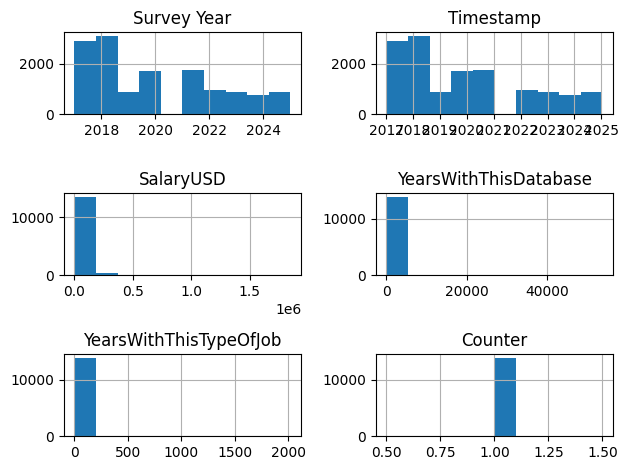

In [29]:
# 3.3.1
data_df.hist()
plt.tight_layout()

Skipping Country as it has 102 categories (>= 25).
Skipping PostalCode as it has 4712 categories (>= 25).
Skipping OtherDatabases as it has 2404 categories (>= 25).
Skipping DatabaseServers as it has 314 categories (>= 25).


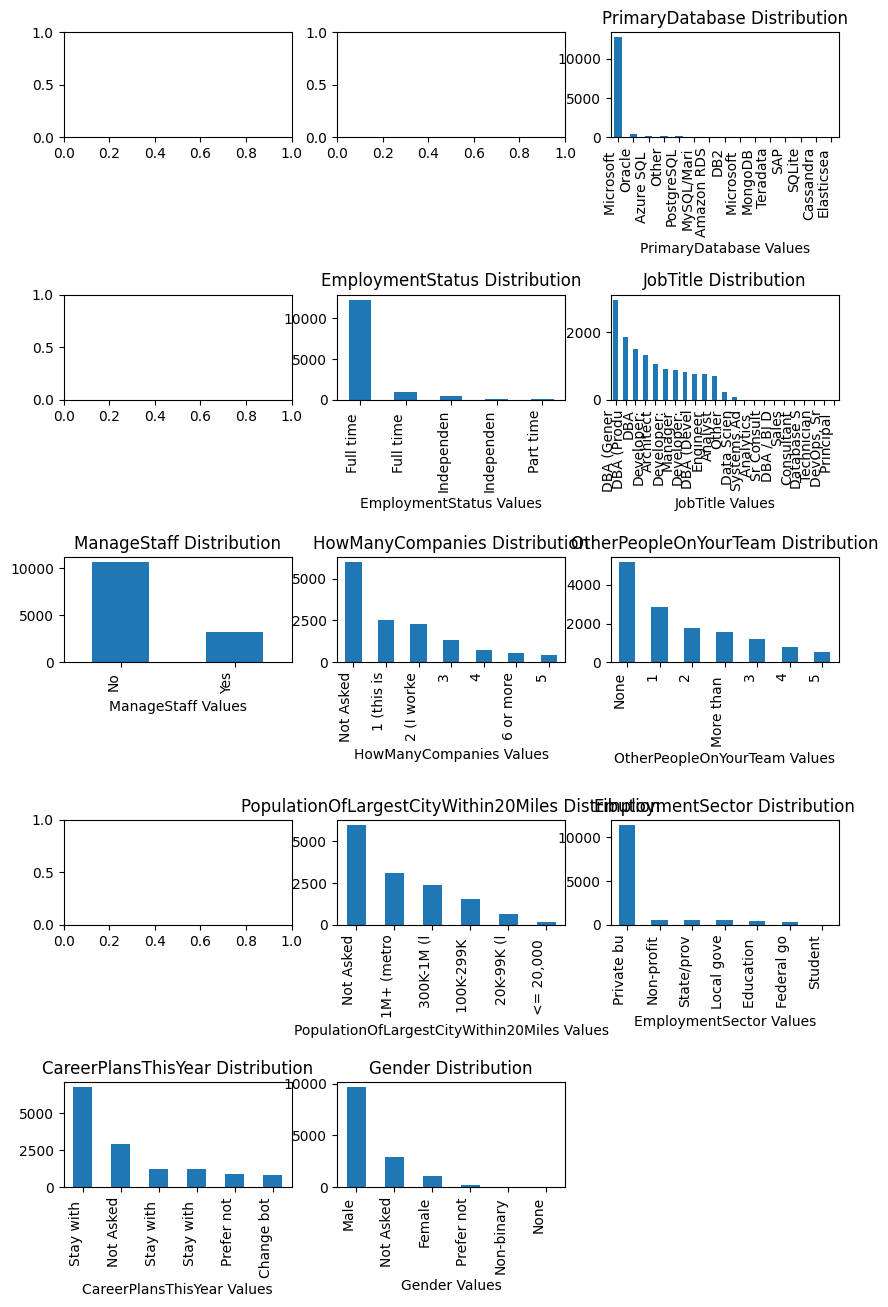

In [30]:
# 3.3.2 
plt.figure(figsize=(10, 15))
tgt_column = 'SalaryUSD'
cat_columns = [x for x in data_df.columns if data_df[x].dtype == 'object' and x != tgt_column]
for i, column in enumerate(data_df[cat_columns].columns):
    plt_rows = len(cat_columns) // 3 + 1
    plt.subplot(plt_rows, 3, i + 1)   
    counts = data_df[column].value_counts()
    if len(counts) < 25:
        counts.plot(kind='bar')
        plt.title(f'{column} Distribution')
        plt.xlabel(f'{column} Values')
        labels = [str(label)[:10] for label in counts.index]
        plt.xticks(range(len(labels)), labels, rotation=90, ha='right')
    else:
        print(f'Skipping {column} as it has {len(counts)} categories (>= 25).')
plt.subplots_adjust(hspace=1.5)
plt.show()

### 3.4 Boxplots for Feature Distributions

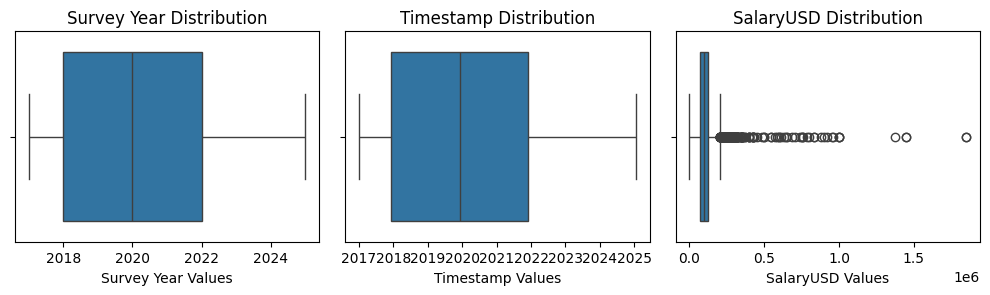

In [31]:
plt.figure(figsize=(10, 8))
for i, column in enumerate(data_df.columns[:3]):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=data_df[column])
    plt.title(f'{column} Distribution')
    plt.xlabel(f'{column} Values')
plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

In [32]:
# 3.5.1
(data_df[
    data_df
        .select_dtypes(include=['number'])
        .columns
        .drop('Counter')]
    .corr()
    .style
        .background_gradient(
            cmap='RdBu_r', 
            vmin=-1, 
            vmax=1))

,Survey Year,SalaryUSD,YearsWithThisDatabase,YearsWithThisTypeOfJob
Survey Year,1.000000,0.133142,-0.001502,0.075420
SalaryUSD,0.133142,1.000000,0.002611,0.045527
YearsWithThisDatabase,-0.001502,0.002611,1.000000,0.034961
YearsWithThisTypeOfJob,0.075420,0.045527,0.034961,1.000000


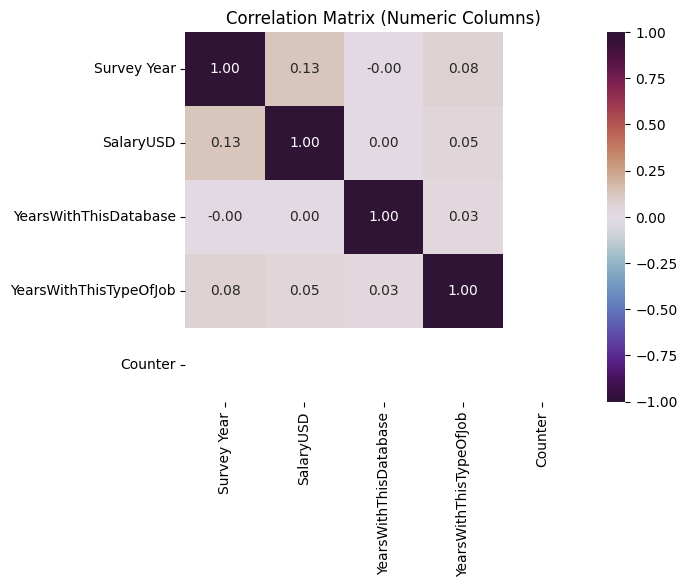

In [33]:
# 3.5.2
numeric_cols = data_df.select_dtypes(include=['number']).corr()
sns.heatmap(numeric_cols, annot=True, vmin=-1, vmax=1, fmt='.2f',
            cmap='twilight_shifted')
plt.title('Correlation Matrix (Numeric Columns)')
plt.show()

### 3.6 EDA Report

In [ ]:
try:
    import ydata_profiling
    profile = ydata_profiling.ProfileReport(data_df)
    profile.to_notebook_iframe()
except ImportError:
    print("Note: ydata-profiling is not installed. EDA report generation will be skipped.")
    print("To enable this feature, ensure you have Python <= 3.12.9 and install: pip install ydata-profiling>=4.1.0")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

<h2 style='color: #ffffff; background-color: #85bb65;'>&nbsp;Machine Learning</h2>

## Step 4: Build The Model Below

Approach:
* Manually remove outlier records prior to X/y split.
* Manually eliminate Features that are obviously irrelevant. 
* Build data-cleansing pipelines for all other pre-processing.
* Use *RandomForestRegressor()* to extract Feature Importance for all remaining columns. 
* Perform *OLS()* fitting on iterations of Top N Features and record R<sup>2</sup> and Adjusted-R<sup>2</sup> values.
* Select Top *N* features and run 12 different Regression models, recording their performance.
* Compare the performance of all 12 Regression models and select the best performant.

### 4.1 Outliers
`SalaryUSD` contains outliers, which must be removed prior to splitting the dataset. This function calculates the IQR whiskers and removes observations outside of the calculated lower/upper bounds. I remove 290 rows (2% of 13,842).

In [35]:
def remove_outliers(df, col):
    '''Remove rows with outlier values.'''
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    inlier_mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
    print(f'{col} outliers trimmed: {lower_bound}, {upper_bound}')
    df_copy = df[inlier_mask].copy()
    df_copy.reset_index(drop=True)
    return df_copy
data_df = remove_outliers(data_df, 'SalaryUSD')
data_df['SalaryUSD'].describe()

SalaryUSD outliers trimmed: -12092.173750000002, 201486.95625


count     13552.000000
mean      94127.967393
std       38522.302776
min          13.000000
25%       67000.000000
50%       94000.000000
75%      120000.000000
max      201000.000000
Name: SalaryUSD, dtype: float64

#### 4.2 X and y Split

In [36]:
X = data_df.loc[:, ~data_df.columns.isin(['SalaryUSD'])]
y = data_df.loc[:, ['SalaryUSD']]

### 4.3 X Columns
* From Exploratory Data Analysis, I sort each column into 1 of 5 buckets: categorical, ordinal, numeric, excluded, and target. 
* Excluded columns are removed because they are either duplicates of some other included column, or the feature is irrelevant.
* Target column contains the value I am attempting to predict.

In [37]:
# 4.3.1
cat_col = ['Country', 
           'PrimaryDatabase', 
           'EmploymentStatus', 
           'JobTitle', 
           'ManageStaff', 
           'EmploymentSector', 
           'CareerPlansThisYear',  # Missing values for 2017.
           'Gender', # Missing values for 2017.
]
ord_col = ['HowManyCompanies', # Missing values for 2017 & 2018.
           'OtherPeopleOnYourTeam', 
           'PopulationOfLargestCityWithin20Miles', # Missing values for 2017 & 2018.
]
num_col = ['Survey Year', 
           'YearsWithThisDatabase', 
           'OtherDatabases', # Garbage. Need to transform.
           'YearsWithThisTypeOfJob', 
           'DatabaseServers', # Missing values for 2021.
]
exl_col = ['Timestamp', # Included in Survey Year.         
           'PostalCode', # Included in Country. Missing values for 2017.
           'Counter', # Irrelevant.
]
tgt_col = ['SalaryUSD']

For categorical columns, I convert from `object` type to `category` type for better dataframe memory management.

In [38]:
# 4.3.2
for col in cat_col + ord_col:
    if col in data_df.columns:
        data_df[col] = data_df[col].astype('category')

### 4.4 Feature Importance
I implement a quick fit of the data into *RandomForestRegressor()* to extract *Feature Importance*.

In [39]:
# 4.4.1
def list_imporant_features(X):
    ''' Rank features by their importance using RandomForestRegressor.'''
    X_preprocessing = X.copy()
    for col in X_preprocessing.columns:
        if col == 'Timestamp':
            X_preprocessing[col] = X_preprocessing[col].astype('int64') / 1e9
        else:
            X_preprocessing[col] = X_preprocessing[col].astype(str)
            X_preprocessing[col] = X_preprocessing[col].astype('category')
            X_preprocessing[col] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_preprocessing[[col]])
    rfr_feature_selection = RandomForestRegressor(n_estimators=100, random_state=RAND, n_jobs=-1)
    rfr_feature_selection.fit(X_preprocessing, y.values.flatten())
    feature_importances = rfr_feature_selection.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': X_preprocessing.columns, 'Importance': feature_importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    return feature_importance_df
features_df = list_imporant_features(X)
(features_df
    .assign(**{'Cumulative Importance': features_df['Importance'].cumsum()})
    .style
        .hide(axis='index')
        .format({'Importance': '{:.4f}', 'Cumulative Importance': '{:.4f}'})
        .bar('Importance', color='gray', align='zero', vmax=1)
        .set_properties(subset=['Feature'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(1)', 'props': [('text-align', 'left')]}])
        .set_caption('<b>Feature Importance</b>'))

Feature,Importance,Cumulative Importance
Country,0.3767,0.3767
YearsWithThisDatabase,0.1365,0.5132
Timestamp,0.0945,0.6077
JobTitle,0.0523,0.6601
OtherDatabases,0.0486,0.7086
PostalCode,0.0431,0.7517
DatabaseServers,0.0419,0.7936
YearsWithThisTypeOfJob,0.0400,0.8336
EmploymentStatus,0.0332,0.8668
OtherPeopleOnYourTeam,0.0208,0.8876


Initilly, I will consider all features (except Excluded). Later I may or may not reduce this list, depending on model performance.

In [40]:
# 4.4.2
def select_top_features(features_df, N):
    '''Select top N features'''
    selected_features = features_df['Feature'].head(N).tolist()
    cat_cols = [col for col in cat_col if col in selected_features]
    ord_cols = [col for col in ord_col if col in selected_features]
    num_cols = [col for col in num_col if col in selected_features]
    print(f'Selected Features: {selected_features}') if DEBUG else None
    print(f'cat_cols: {cat_cols}\nord_cols: {ord_cols}\nnum_cols: {num_cols}') if DEBUG else None
    return cat_cols, ord_cols, num_cols

cat_cols, ord_cols, num_cols = select_top_features(features_df, 30)

### 4.5 Build Data Cleaning Pipes
* After X and y split, I build data cleansing pipelines. Each column (not Excluded and not the Target), is first filtered for whether it is included or not (based on the Top N Features function).
* Next, each column is assigned a type (Categorical, Ordinal, Numeric) and is routed to the respective ColumnTransformer.
* Within each ColumnTransformer, the column is processed through a series of user-defined Functions, Imputers, and Encoders.
* The output of the process is standardized, clean data ready for modeling.

#### 4.5.1 Functions

In [41]:
# 4.5.1.1
def remove_bad_values(df):
    '''Removes invalid Years of Experience values from numeric columns.'''
    df_copy = df.copy()
    cols_to_check = ['YearsWithThisDatabase', 'YearsWithThisTypeOfJob']
    for col in cols_to_check:
        if col in df_copy.columns:
            try:
                df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')
                df_copy[col] = df_copy[col].apply(lambda x: np.nan if pd.notna(x) and x > 99 else x)
            except (KeyError, ValueError):
                pass
    return df_copy
invalid_ft = FunctionTransformer(remove_bad_values)

In [42]:
# 4.5.1.2
def remove_not_asked(df):
    '''Remove Not Asked values from all columns.'''
    df_copy = df.copy()
    df_copy = df_copy.replace('Not Asked', np.nan).infer_objects(copy=False)
    return df_copy
not_asked_ft = FunctionTransformer(remove_not_asked)

In [43]:
# 4.5.1.3
def convert_list_to_length(df):
    '''Counts number of items in a comma-delimited string.'''
    df_copy = df.copy()
    if 'OtherDatabases' in df_copy.columns:
        df_copy['OtherDatabases'] = df_copy['OtherDatabases'].fillna('')
        df_copy['OtherDatabases'] = np.where(df_copy['OtherDatabases'] == '', 0, df_copy['OtherDatabases'].str.count(',') + 1)
        df_copy['OtherDatabases'].value_counts()
    return df_copy
list_len_ft = FunctionTransformer(convert_list_to_length)

In [44]:
# 4.5.1.4
def convert_to_numeric(df):
    '''Convert dtype to numeric.'''
    df_copy = df.copy()
    for col in df_copy.columns:
        try:
            df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce', downcast='integer')
        except ValueError as e:
            print(f'Warning: Error converting column {col}: {e}')
    return df_copy
number_ft = FunctionTransformer(convert_to_numeric)

In [45]:
# 4.5.1.5
def convert_to_category(df):
    '''Convert dtype to category.'''
    df_copy = df.copy()
    for col in df_copy.columns:
        if df_copy[col].dtype == 'object':
            df_copy[col] = df_copy[col].astype(str).astype('category')
    return df_copy
category_ft = FunctionTransformer(convert_to_category)

In [46]:
# 4.5.1.6
def convert_to_string(df): 
    '''Convert dtype to string.'''
    df_copy = df.copy()
    for col in df_copy.columns:
        df_copy[col] = df_copy[col].astype(str)
    return df_copy
string_ft = FunctionTransformer(convert_to_string)

#### 4.5.2 Imputers

In [47]:
# 4.5.2.1
imp_num = SimpleImputer(strategy='median')

In [48]:
# 4.5.2.2
imp_cat = SimpleImputer(strategy='most_frequent')

#### 4.5.3 Encoders

In [49]:
# 4.5.3.1
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', min_frequency=0.0001)

In [50]:
# 4.5.3.2
companies_ord  = ['1 (this is the only company where I\'ve had this kind of position)',
                  '2 (I worked at another similar position elsewhere before this one)',
                  '3', '4', '5', '6 or more']
team_ord       = ['None', '1', '2', '3', '4', '5', 'More than 5']
population_ord = ['<= 20,000 (town)', '20K-99K (large town)', '100K-299K (city)',
                  '300K-1M (large city)', '1M+ (metropolis)']
ord_cats = [companies_ord, 
            team_ord, 
            population_ord
]
oe = OrdinalEncoder(categories=ord_cats, handle_unknown='use_encoded_value', unknown_value=-1)

#### 4.5.4 Column Transformers
All remaining data cleansing and pre-processing is performed within ColumnTransformers and Pipelines. This prevents data leakage, enforces uniform and repeatable transformations, and is reusable for each Regression model.

For all columns, I remove 'Not Asked' values as these represent missing data and are converted to *NaN*. Pipe **pipeline-1** processes Categorical data, **pipeline-2** is for Ordinal data, and **pipeline-3** is for Numerical data. *NaN* values are corrected by imputing the mean or most frequent values.

One feature, `OtherDatabases`, is a comma-delimited list of databases the respondent has familiarity or experience with. I transformed that to a Numerical column as a list length, with the number if items as the number of other databases.

I also remove invalid values for some Numeric features. For example, `YearsWithThisDatabase` and `YearsWithThisTypeOfJob` are measures in years and should never be greater than 99. Outliers are converted to *NaN* and subsequently imputed with the mean.

In [51]:
# 4.5.4.1 pipeline-1
ct_nom_pipe = make_pipeline(not_asked_ft, string_ft, imp_cat, ohe)

In [52]:
# 4.5.4.2 pipeline-2
ct_ord_pipe = make_pipeline(not_asked_ft, category_ft, imp_cat, oe)

In [53]:
# 4.5.4.3 pipeline-3
ct_num_pipe = make_pipeline(not_asked_ft, invalid_ft, list_len_ft, number_ft, imp_num)

In [54]:
# 4.5.4.4 ColumnTransformer
column_trans = make_column_transformer(
    (ct_nom_pipe, cat_cols),
    (ct_ord_pipe, ord_cols), 
    (ct_num_pipe, num_cols), 
    remainder='drop')
print(f'cat_cols: {cat_cols}\nord_cols: {ord_cols}\nnum_cols: {num_cols}\ntgt_col : {tgt_col}\nexl_cols: {exl_col}') if DEBUG else None
column_trans.set_output(transform='pandas')

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('functiontransformer-1',
                                                  FunctionTransformer(func=<function remove_not_asked at 0x146531300>)),
                                                 ('functiontransformer-2',
                                                  FunctionTransformer(func=<function convert_to_string at 0x146530ae0>)),
                                                 ('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown...
                                                  FunctionTransformer(func=<function remove_bad_values at 0x146530f40>)),
                                                 ('functiontransformer-3',
                                                  FunctionTransformer(func=<function convert_list_to_length at 0x146531a80>)),
                                                 ('functiontransformer-4',
                                                  FunctionTransformer(func=<function convert_to_numeric at 0x146530a40>)),
                                                 ('simpleimputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Survey Year', 'YearsWithThisDatabase',
                                  'OtherDatabases', 'YearsWithThisTypeOfJob',
                                  'DatabaseServers'])])

<div><img src='images/column_transformer.png' /></div>

### 4.6 Variance and Adjusted-R²
Now that the data is filtered for outliers and ready for data cleansing pipelines, I will iterate through the Top N features and obtain the *R<sup>2</sup>* and *Adjusted R<sup>2</sup>* values using OLS.

In [55]:
# 4.6.1
for i in range(features_df.shape[0]+1)[1::1]:
    cat_cols, ord_cols, num_cols = select_top_features(features_df, i)
    column_trans_ols = make_column_transformer(
        (ct_nom_pipe, cat_cols),
        (ct_ord_pipe, ord_cols), 
        (ct_num_pipe, num_cols), 
        remainder='drop')
    try:
        model_summary = sm.OLS(y, sm.add_constant(column_trans_ols.fit_transform(X))).fit()
    except:
        pass
    print(f'Features selected: {i:>2}. R-squared: {model_summary.rsquared:,.4f}. Adjusted R-squared: {model_summary.rsquared_adj:,.4f}')

Features selected:  1. R-squared: 0.4121. Adjusted R-squared: 0.4084
Features selected:  2. R-squared: 0.5341. Adjusted R-squared: 0.5311
Features selected:  3. R-squared: 0.5341. Adjusted R-squared: 0.5311
Features selected:  4. R-squared: 0.5688. Adjusted R-squared: 0.5656
Features selected:  5. R-squared: 0.5725. Adjusted R-squared: 0.5693
Features selected:  6. R-squared: 0.5725. Adjusted R-squared: 0.5693
Features selected:  7. R-squared: 0.5725. Adjusted R-squared: 0.5693
Features selected:  8. R-squared: 0.5765. Adjusted R-squared: 0.5732
Features selected:  9. R-squared: 0.5945. Adjusted R-squared: 0.5912
Features selected: 10. R-squared: 0.5945. Adjusted R-squared: 0.5912
Features selected: 11. R-squared: 0.5945. Adjusted R-squared: 0.5912
Features selected: 12. R-squared: 0.5945. Adjusted R-squared: 0.5912
Features selected: 13. R-squared: 0.5945. Adjusted R-squared: 0.5912
Features selected: 14. R-squared: 0.5945. Adjusted R-squared: 0.5912
Features selected: 15. R-squared: 

In [56]:
# 4.6.2
print(model_summary.summary())

                            OLS Regression Results                            
Dep. Variable:              SalaryUSD   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.635
Method:                 Least Squares   F-statistic:                     168.1
Date:                Sat, 12 Apr 2025   Prob (F-statistic):               0.00
Time:                        10:43:14   Log-Likelihood:            -1.5543e+05
No. Observations:               13552   AIC:                         3.111e+05
Df Residuals:                   13410   BIC:                         3.122e+05
Df Model:                         141                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.415e+06    1.2e+05    -11.838      0.0

In [57]:
# 4.6.3 Manually cap the Top N features to 15. (could use KBest() for automatic selection.)
cat_cols, ord_cols, num_cols = select_top_features(features_df, 15)

### 4.7 Build Modeling Pipes
I will run the cleansed data through multiple regression models. I will generally use default values (except n_jobs). 

For *SVR()*, the hyper-parameters were obtained using *GridSearchCV()* and *RandomSearchCV()* during development of this workbook. The interim code used to obtain those hyper-parameters is discarded and outside of the scope of this exercise.

#### 4.7.1 Models

In [58]:
models = {
    'Polynomial Regression': Pipeline([
        ('column_transform', column_trans),
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2)),
        ('linreg', LinearRegression(n_jobs=-1)),
    ]),
    'Decision Tree Regressor': Pipeline([
        ('column_transform', column_trans),
        ('dtr', DecisionTreeRegressor(random_state=RAND)),
    ]),
    'K-Nearest Neighbors Regressor': Pipeline([
        ('column_transform', column_trans),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_jobs=-1)),
    ]),
    'Elastic Net Regression': Pipeline([
        ('column_transform', column_trans),
        ('scaler', StandardScaler()),
        ('elasticnet', ElasticNet()),
    ]),
    'Gradient Boosting Regressor': Pipeline([
        ('column_transform', column_trans),
        ('gbr', GradientBoostingRegressor(random_state=RAND)),
    ]),
    'Random Forest Regressor': Pipeline([
        ('column_transform', column_trans),
        ('rfr', RandomForestRegressor(random_state=RAND, n_jobs=-1)),
    ]),
    'Support Vector Regressor': Pipeline([
        ('column_transform', column_trans),
        ('scaler', StandardScaler()),
        ('svr', SVR(
            kernel='linear', 
            degree=2, 
            gamma='auto', 
            C=np.float64(28.0), 
            epsilon=np.float64(0.65)
        )),
    ]),
    'Lasso Regression': Pipeline([
        ('column_transform', column_trans),
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=1.0)),
    ]),
    'Ridge Regression': Pipeline([
        ('column_transform', column_trans),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=1.0)),
    ]),
    'Bayesian Ridge Regression': Pipeline([
        ('column_transform', column_trans),
        ('scaler', StandardScaler()),
        ('bayesianridge', BayesianRidge()),
    ]),
    'HistGradientBoostingRegressor': Pipeline([
        ('column_transform', column_trans),
        ('hgb', HistGradientBoostingRegressor(random_state=RAND)),
    ]),
    'Linear Regression': Pipeline([
        ('column_transform', column_trans),
        ('linreg', LinearRegression(n_jobs=-1)),
    ]),
}

#### 4.7.2 Train and Test Split

In [59]:
def custom_train_test_split(X, y, survey_year_column, test_year):
    '''Split train and test sets by Survey Year'''
    train_mask = X[survey_year_column] < test_year
    test_mask = X[survey_year_column] == test_year
    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]
    return X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RAND)
#X_train, X_test, y_train, y_test = custom_train_test_split(X, y, survey_year_column='Survey Year', test_year=2025)
print(f'features: {[col for col in X.columns]}\ntarget: {[col for col in y.columns]}') if DEBUG else None
print(f'data_df: {data_df.shape}\nX_train: {X_train.shape}\nX_test: {X_test.shape}\ny_train: {y_train.shape}\ny_test: {y_test.shape}')

data_df: (13552, 20)
X_train: (9486, 19)
X_test: (4066, 19)
y_train: (9486, 1)
y_test: (4066, 1)


#### 4.7.3 Fit Pipelines
Fitting and training. For each model, I run KFold() and store the results in a list. Then, I calculate the mean performance across all folds for each model.

This process runs in about 6½ minutes on current hardware.

In [60]:
try:
    cv_results
except NameError:
    cv_results = {}

if len(cv_results) == 0:
    for model_name, model in models.items():
        try:
            mse_scores = []
            r2_scores = []
            mae_scores = []
            all_y_pred = []
            all_val_indices = []

            start_perf = time.perf_counter()
            start_process = time.process_time()
            kf = KFold(n_splits=5, shuffle=True, random_state=RAND)
            for train_index, val_index in kf.split(X_train, y_train):
                X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
                y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
                model.fit(X_train_fold, y_train_fold.values.flatten())
                y_pred = model.predict(X_val_fold)
                mse_scores.append(mean_squared_error(y_val_fold, y_pred))
                r2_scores.append(r2_score(y_val_fold, y_pred))
                mae_scores.append(mean_absolute_error(y_val_fold, y_pred))
                all_y_pred.append(y_pred)
                all_val_indices.append(val_index)
    
            mse = np.mean(mse_scores)
            rmse = np.sqrt(mse)
            rmse_percent = (rmse / np.mean(y_train)) * 100
            consolidated_y_pred = np.concatenate(all_y_pred)
            consolidated_val_indices = np.concatenate(all_val_indices)
            y_pred_df = pd.DataFrame({'y_pred': consolidated_y_pred}, index=consolidated_val_indices)
            y_pred_df = y_pred_df.sort_index()
            end_perf = time.perf_counter()
            end_process = time.process_time()

            cv_results[model_name] = {
                'MSE': mse,
                'RMSE': rmse,
                'RMSE (%)': rmse_percent,
                'MAE': np.mean(mae_scores),
                'R2': np.mean(r2_scores).round(4),
                'y_pred': y_pred_df['y_pred'].values,
                'real_time': end_perf - start_perf,
                'cpu_time': end_process - start_process,
            }
            print(f'Model {model_name} trained successfully.') if DEBUG else None
        except Exception as e:
            logging.error(f'Model {model_name} crashed: {e}', exc_info=True)
            continue

/var/folders/6v/ckntf1h540q_4xl79_lpxhkm0000gn/T/ipykernel_33402/2927992391.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy = df_copy.replace('Not Asked', np.nan).infer_objects(copy=False)
/var/folders/6v/ckntf1h540q_4xl79_lpxhkm0000gn/T/ipykernel_33402/2927992391.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy = df_copy.replace('Not Asked', np.nan).infer_objects(copy=False)
/var/folders/6v/ckntf1h540q_4xl79_lpxhkm0000gn/T/ipykernel_33402/2927992391.py:5: FutureWarning: Downcasting behavior in `replace` is 

<h2 style='color: #ffffff; background-color: #85bb65;'>&nbsp;Evaluation</h2>

## Step 5: Evaluate The Model Performance

In [61]:
# 5.1.1
def cv_results_to_dataframe(cv_results):
    '''Converts a cross-validation results dictionary to a pivoted DataFrame.'''
    data = []
    for model_name, metrics in cv_results.items():
        row = {'Model': model_name}
        for metric, value in metrics.items():
            if metric != 'y_pred':
                row[metric] = value
        data.append(row)
    df = pd.DataFrame(data)
    df = df.sort_values(by='R2', ascending=False).reset_index(drop=True)
    return df

In [62]:
# 5.1.2
(cv_results_to_dataframe(cv_results)
    .style
        .format({'MSE': '{:,.0f}', 'RMSE': '{:,.0f}', 'RMSE (%)': '{:,.2f}%', 'MAE': '{:,.0f}', 'R2': '{:,.4f}'}) 
        .set_caption('<b>Ranked Model by R2 in descending order</b>')
        .set_properties(subset=['Model'], **{'text-align': 'left'})
        .set_table_styles([{'selector': 'th:nth-child(2)', 'props': [('text-align', 'left')]}])
        .background_gradient(
            subset='R2', 
            cmap='RdBu', 
            vmin=-1, 
            vmax=1)
        .background_gradient(
            subset='real_time', 
            cmap='RdBu_r', 
            vmin=0, 
            vmax=20))

,Model,MSE,RMSE,RMSE (%),MAE,R2,real_time,cpu_time
0,HistGradientBoostingRegressor,"516,487,818","22,726",24.18%,"16,723",0.6510,3.124822,34.497156
1,Random Forest Regressor,"546,741,019","23,382",24.87%,"17,151",0.6305,2.403407,20.687446
2,Linear Regression,"548,421,502","23,418",24.91%,"17,455",0.6294,0.458533,2.611643
3,Bayesian Ridge Regression,"551,941,921","23,493",24.99%,"17,503",0.6270,0.539944,0.746942
4,Ridge Regression,"552,134,202","23,498",25.00%,"17,503",0.6269,0.369421,0.369604
5,Lasso Regression,"553,618,770","23,529",25.03%,"17,514",0.6259,3.245129,3.245540
6,Gradient Boosting Regressor,"563,324,635","23,734",25.25%,"17,782",0.6193,4.341957,4.343152
7,Support Vector Regressor,"563,606,294","23,740",25.25%,"17,525",0.6191,9.640593,9.642217
8,Elastic Net Regression,"607,008,257","24,638",26.21%,"18,734",0.5897,0.447409,2.505981
9,K-Nearest Neighbors Regressor,"727,687,293","26,976",28.70%,"20,151",0.5082,0.566079,5.344912


**5.2 Predictive Performance**
* Ensemble models (*HistGradientBoostingRegressor, RandomForestRegressor, GradientBoostingRegressor*) achieved the highest predictive accuracy, with R<sup>2</sup> values ranging from 0.6193 to 0.6510. This indicates that these models effectively capture complex, non-linear relationships within the data.
* Linear models (*LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge*) also demonstrated reasonable predictive power, with R<sup>2</sup> values around 0.60.
* *DecisionTreeRegressor* and *KNeighborsRegressor* showed moderate performance, while Polynomial Regression performed very poorly (R<sup>2</sup> of -10.1038), indicating severe overfitting.

**5.3 Error Magnitude**
* The Root Mean Squared Error (RMSE) ranged from approximately $22,726 to $127,004, reflecting the variability in prediction accuracy across models. The ensemble models generally exhibited lower RMSE values, aligning with their higher R<sup>2</sup> scores.
* The RMSE (%) values, ranging from 24.18% to 135.10%, provide a measure of prediction error. *Polynomial Regression*'s extremely high RMSE (%) further emphasizes its lack of fit. 

**5.4 Computational Efficiency**
* Linear models were generally the most efficient, with training under 10 seconds.
* Polynomial Regression was exceptionally inefficient, taking over 353 seconds. This highlights its computational burden, especially with higher-degree polynomials. 

**5.5 Parallelization**
* Most models used multi-threading with `n_jobs` parameter, resulting in faster training times.
* *Elastic Net* and *HistGradientBoostingRegressor* demonstrated internal parallelization, even without explicit n_jobs settings.
* *Polynomial Regression* did not use multi-threading, contributing to its poor performance.

The Ensemble regression models generally performed best. Polynomial Regression performed exceptionally poor.

<h2 style='color: #ffffff; background-color: #85bb65;'>&nbsp;Interpretation</h2>

## Step 6: Describe And Interpret The Model

In [63]:
# 6.1.1
plot_data = []
for model_name, results in cv_results.items():
    y_pred = results['y_pred']
    r2 = results['R2']  
    for actual, predicted in zip(y_train['SalaryUSD'].values, y_pred):
        plot_data.append({
            'Actual Salary': actual,
            'Predicted Salary': predicted,
            'Model': f'{model_name} (R2: {r2:.4f})'  
        })

plot_df = pd.DataFrame(plot_data)

min_val = min(plot_df['Actual Salary'].min(), plot_df['Actual Salary'].min())
max_val = max(plot_df['Actual Salary'].max(), plot_df['Actual Salary'].max())

fig = px.scatter(
    plot_df,
    x='Actual Salary',
    y='Predicted Salary',
    animation_frame='Model',
    title='Actual vs. Predicted Salary (Animated)',
    opacity=0.5,
    size_max=1,
    range_x=[min_val, max_val],
    range_y=[min_val, max_val],
)

fig.add_trace(go.Scatter(x=[min_val, max_val], y=[min_val, max_val], mode='lines',
                         line=dict(color='red', dash='dash'), name='Identity Line (1:1)'))

fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.update_layout(
    yaxis=dict(
        scaleanchor='x',
        scaleratio=1,
    ),
    xaxis=dict(
        constrain='domain',
        scaleanchor='y',
        scaleratio=1
    ),
    width=800,
    height=800
)

fig.show()

<div><img src='images/animated_plot.gif' /></div>

Animated scatterplot showing Actual vs Predicted `SalaryUSD` for each regression model. The best performing models have less scatter around the Identity Line.

In [64]:
# 6.1.2
fig = go.Figure()

for model in plot_df['Model'].unique():
    df_model = plot_df[plot_df['Model'] == model]
    fig.add_trace(go.Scatter(
        x=df_model['Actual Salary'],
        y=df_model['Predicted Salary'],
        mode='markers',
        opacity=0.5,
        marker=dict(
            line=dict(
                color='white',
                width=0.5
            )
        ),
        name=model
    ))

fig.add_trace(go.Scatter(x=[min_val, max_val], y=[min_val, max_val], mode='lines',
                         line=dict(color='red', dash='dash'), name='Identity Line (1:1)'))

fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.update_layout(
    title='Actual vs. Predicted Salary',
    yaxis=dict(
        scaleanchor='x',
        scaleratio=1,
        range=[min_val, max_val]
    ),
    xaxis=dict(
        constrain='domain',
        scaleanchor='y',
        scaleratio=1,
        range=[min_val, max_val]
    ),
    width=1000,  
    height=600  
)

fig.show()

<div><img src='images/static_plot.png' /></div>

Static-image scatterplot showing Actual vs Predicted `SalaryUSD` for each regression model. The best performing models have less scatter around the Identity Line.

### 6.2 Findings
This analysis aimed to predict SalaryUSD based on a set of relevant features. While the initial goal was to achieve an Adjusted R<sup>2</sup> of at least 70%, the best-performing models reached an R<sup>2</sup> of approximately 0.65. This indicates that while the models can explain a significant portion of the variance in salary, there is still substantial unexplained variability. Several key findings emerged: 

**6.2.1 Feature Importance**
The feature importance analysis revealed that `Country` was the strongest predictor of `SalaryUSD`, followed by `JobTitle` and `YearsWithThisTypeOfJob`. This suggests that geographical location, job role, and experience are the most influential factors in determining salary within this dataset. However, it's important to note that `Country` has a high cardinality (102 unique values), which might contribute to overfitting. 

**6.2.2 Feature Selection**
The *OLS* regression analysis showed that Adjusted-R<sup>2</sup> plateaued around 0.66 after including approximately 15 features. This suggests that adding more features beyond this point did not significantly improve the model's explanatory power and may have introduced noise. Consequently, the subsequent models were trained using the top 12 features (after excluding 3 manually eliminated). 

**6.2.3 Model Performance**
* Ensemble models (*HistGradientBoostingRegressor, RandomForestRegressor, GradientBoostingRegressor*) consistently outperformed linear models, achieving the highest R<sup>2</sup> values (around 0.63-0.65) and demonstrating better ability to capture non-linear relationships in the data.
* Linear models (*LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge*) provided reasonably good performance (R<sup>2</sup> around 0.60) with significantly lower computational cost. This makes them a viable option when efficiency and interpretability are crucial.
* *Polynomial Regression* showed the poorest performance (R<sup>2</sup> of -10.1038) and the highest computational cost, indicating severe overfitting. This model's complexity appears to be unsuitable for the dataset.

**6.2.4 Model Efficiency**
* The computational cost varied significantly across models. Linear models were generally the fastest, while *Polynomial Regression* was the slowest.
* Multi-threading (using the `n_jobs` parameter) provided performance benefits for some models (*KNeighborsRegressor, RandomForestRegressor, Linear Regression*), but not for all. Notably, *ElasticNet* and *HistGradientBoostingRegressor* exhibited internal parallelization. 

### 6.3 Opportunities
* The maximum achievable R<sup>2</sup> of 0.65 suggests that important predictors of salary might be missing from the dataset.
* Further research should explore feature engineering to incorporate factors such as:
  * Cost of living indices for different locations.
  * Detailed skill sets and certifications.
  * Company size and revenue.
  * Industry-specific factors.
* To address the high cardinality of the `Country` feature, consider:
  * Grouping countries into geographical regions or economic zones.
  * Using embedding techniques to represent countries in a lower-dimensional space.
* Hyper-parameter tuning (using *GridSearchCV or RandomizedSearchCV*) could potentially further improve the performance of individual models, particularly for *SVR*, which showed sensitivity to parameter settings.
* Exploring more advanced machine learning libraries, such as *XGBoost* or *LightGBM*, known for their efficiency and performance, is another avenue for future investigation.

<h2 style='color: #ffffff; background-color: #85bb65;'>&nbsp;Sources</h2>

<a id='source1'>1</a>. <b>Brent Ozar Unlimited</b>
<br>&nbsp;&nbsp;&nbsp;&nbsp;<em>Data Professional Salary Survey Results</em>. 2025 Jan 14.
<br>&nbsp;&nbsp;&nbsp;&nbsp;<a href='https://www.brentozar.com/archive/2025/01/announcing-the-2025-data-professional-salary-survey-results/'>https://www.brentozar.com/archive/2025/01/announcing-the-2025-data-professional-salary-survey-results/</a>